# Feature Engineering

This notebook is created to engineer features grounded in EDA insights, that encodes all categoricals, and saves `telco_featured.csv`.

---
### What was derived from EDA which in turn shall drive feature choices ?
| Insight | Feature we will build |
|---|---|
| TotalCharges ≈ tenure × MonthlyCharges (multicollinearity) | `avg_monthly_spend` |
| First-year cliff: ~50% churn in 0-12 months | `early_tenure`, `tenure_group_encoded` |
| Month-to-month --> 42% churn vs 3% for 2-year | `is_month_to_month`, `high_risk_combo` |
| Electronic check skews toward churners | `is_electronic_check`, `is_auto_payment` |
| No protective services --> ~2x churn rate | `has_protective_services`, `num_add_on_services` |
| Senior who are alone = elevated risk | `senior_alone` |

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR  = PROJECT_ROOT / "data" / "processed"
CLEAN_PATH     = PROCESSED_DIR / "telco_clean.csv"
FEATURED_PATH  = PROCESSED_DIR / "telco_featured.csv"

raw = pd.read_csv(CLEAN_PATH)
print("Loaded shape:", raw.shape)
raw.head(3)

Loaded shape: (7032, 20)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


### Label Engineering

The target column `Churn` is a string (`"Yes"` / `"No"`). Every ML algorithm needs a **numeric** target.

We map `Yes as 1` (churned) and `No as 0` (retained) using an explicit dictionary which is more readable and deterministic than `LabelEncoder`, which can silently reverse the mapping if the minority class happens to sort first.

In [3]:
feat = raw.copy()

feat["Churn"] = feat["Churn"].map({"Yes": 1, "No": 0})

print("Churn value counts after encoding:")
print(feat["Churn"].value_counts().to_string())
print(f"\nChurn rate: {feat['Churn'].mean():.1%} ")

Churn value counts after encoding:
Churn
0    5163
1    1869

Churn rate: 26.6% 


### 1: Numerical Feature Engineering

### 1a. Average monthly spend
`TotalCharges` is highly correlated with `tenure` (r ≈ 0.83 from EDA) as it tells us how long someone has been a customer almost as much as it tells us how much they pay. Dividing by `tenure` isolates the **per-month spend** independently of loyalty duration.

### 1b. Charges-to-average ratio
If `MonthlyCharges / avg_monthly_spend > 1`, the customer is now paying *more* per month than their historical average, a proxy for a price increase since they joined. 
Price escalation is a leading churn driver: the customer expected the original rate and may feel cheated.

In [4]:
# 1a: average monthly spend (removes the tenure-TotalCharges confound)
feat["avg_monthly_spend"] = feat["TotalCharges"] / feat["tenure"].clip(lower=1)

# 1b: ratio of current month charge to historical average
#       > 1  =>  customer is paying more now than on average  =>  possible price escalation signal
#       < 1  =>  customer may have gotten a discount recently
feat["charges_to_avg_ratio"] = feat["MonthlyCharges"] / feat["avg_monthly_spend"].clip(lower=0.01)

print(feat[["tenure", "MonthlyCharges", "TotalCharges",
            "avg_monthly_spend", "charges_to_avg_ratio"]].describe().round(2))

        tenure  MonthlyCharges  TotalCharges  avg_monthly_spend  \
count  7032.00         7032.00       7032.00            7032.00   
mean     32.42           64.80       2283.30              64.80   
std      24.55           30.09       2266.77              30.19   
min       1.00           18.25         18.80              13.78   
25%       9.00           35.59        401.45              36.18   
50%      29.00           70.35       1397.48              70.37   
75%      55.00           89.86       3794.74              90.18   
max      72.00          118.75       8684.80             121.40   

       charges_to_avg_ratio  
count               7032.00  
mean                   1.00  
std                    0.05  
min                    0.64  
25%                    0.98  
50%                    1.00  
75%                    1.02  
max                    1.45  


### 1c. Log transforms
`MonthlyCharges` and `TotalCharges` are right-skewed (especially `TotalCharges`, where new customers cluster near zero). 
Log transforms are done to compress the long tail and help **linear models** (Logistic Regression, SVM) fit the distribution.
Tree-based models are less sensitive to this but it doesn't hurt them either.

`log1p(x) = log(1 + x)` avoids `log(0) = -inf` for any zero values.

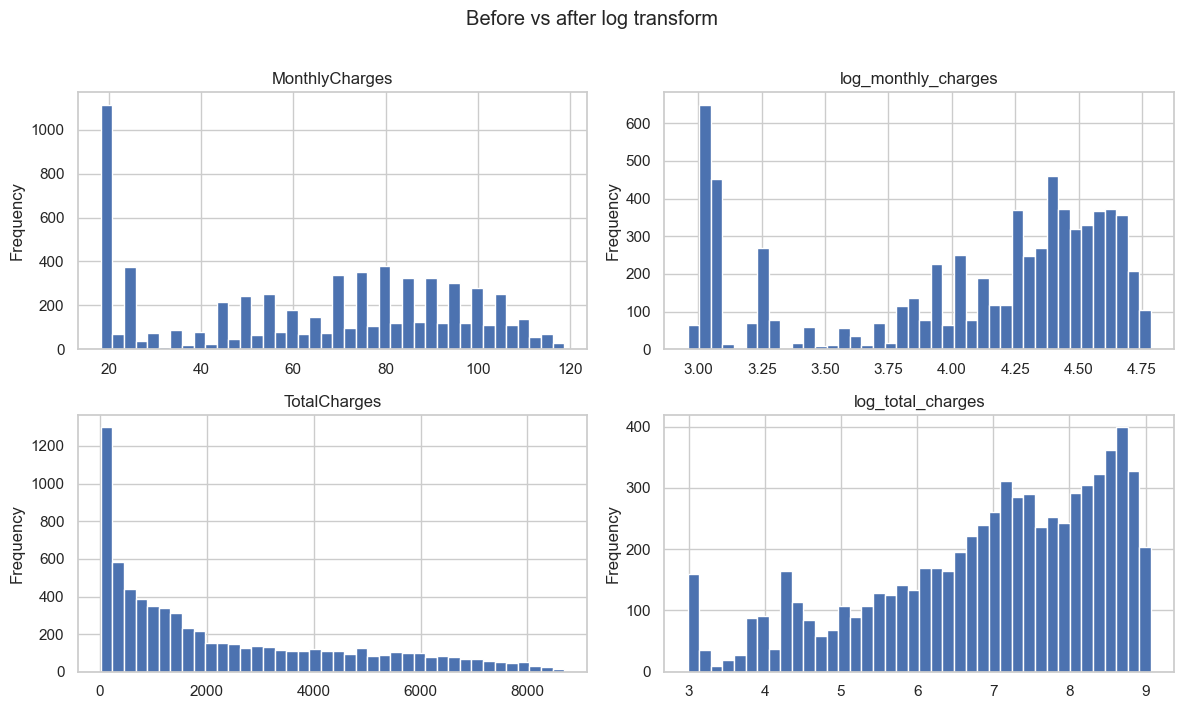

In [5]:
feat["log_monthly_charges"] = np.log1p(feat["MonthlyCharges"])
feat["log_total_charges"]   = np.log1p(feat["TotalCharges"])

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, col in zip(axes.flat, ["MonthlyCharges", "log_monthly_charges",
                                "TotalCharges",   "log_total_charges"]):
    feat[col].plot(kind="hist", bins=40, ax=ax)
    ax.set_title(col)
plt.suptitle("Before vs after log transform", y=1.01)
plt.tight_layout()
plt.show()

### 1d. Tenure group (ordinal encoding)
EDA showed churn is **not linear with tenure**, it drops sharply after 12 months and again after 24. Binning turns this step-function relationship into something simpler for linear models to learn.

We encode the bins as integers 0–3 (ordinal) since the groups have a natural ordering: 0-12m < 13-24m < 25-48m < 49-72m.

In [6]:
tenure_bins   = [0, 12, 24, 48, 72]
tenure_labels = ["0-12m", "13-24m", "25-48m", "49-72m"]

feat["tenure_group"] = pd.cut(
    feat["tenure"], bins=tenure_bins, labels=tenure_labels, include_lowest=True
)

# Ordinal encoding: each label maps to its position index
tenure_ordinal = {label: i for i, label in enumerate(tenure_labels)}
feat["tenure_group_encoded"] = feat["tenure_group"].map(tenure_ordinal)

print("Tenure group distribution:")
print(feat["tenure_group"].value_counts().sort_index().to_string())
print("\nChurn rate per group:")
print(
    feat.groupby("tenure_group", observed=True)["Churn"]
    .mean().rename("churn_rate").round(3).to_string()
)

Tenure group distribution:
tenure_group
0-12m     2175
13-24m    1024
25-48m    1594
49-72m    2239

Churn rate per group:
tenure_group
0-12m     0.477
13-24m    0.287
25-48m    0.204
49-72m    0.095


### 2: Service Aggregation Features

The six add-on service columns (OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies) each have three values: `"Yes"` / `"No"` / `"No internet service"`. We treat the last two as equivalent meaning the service is **not active**.

### Why aggregate?
EDA showed a clear *dose-response*: each protective service reduced churn. Rather than the model having to discover this across 6 separate columns, hand it an explicit count. This is a form of **domain knowledge injection**, basically telling the model what the EDA explained.

| Feature | What it captures |
|---|---|
| `num_add_on_services` | How "locked in" a customer is (0-6 scale) |
| `has_protective_services` | Security/backup/support adoption (2x churn difference) |
| `has_streaming` | Engagement with entertainment bundle |

In [7]:
service_addon_cols = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]

# Count how many add-on services are active (Yes = 1, everything else = 0)
feat["num_add_on_services"] = (feat[service_addon_cols] == "Yes").sum(axis=1)

# Binary flag: has at least one security/support service
protective_cols = ["OnlineSecurity", "TechSupport", "OnlineBackup", "DeviceProtection"]
feat["has_protective_services"] = (feat[protective_cols] == "Yes").any(axis=1).astype(int)

# Binary flag: watching content through the platform (creates usage habit)
feat["has_streaming"] = (
    (feat["StreamingTV"] == "Yes") | (feat["StreamingMovies"] == "Yes")
).astype(int)

# Validate - churn should decrease with more services
print("Churn rate by number of add-on services:")
print(
    feat.groupby("num_add_on_services")["Churn"]
    .mean().rename("churn_rate").round(3).to_string()
)
print("\nChurn rate: has_protective_services")
print(feat.groupby("has_protective_services")["Churn"].mean().round(3).to_string())

Churn rate by number of add-on services:
num_add_on_services
0    0.215
1    0.458
2    0.358
3    0.274
4    0.224
5    0.125
6    0.053

Churn rate: has_protective_services
has_protective_services
0    0.298
1    0.245


### 3: Risk Profile Features (Binary Interaction Features)

These combine two or more raw signals that EDA showed to be independently predictive. Interaction features let **linear models** detect non-additive effects they'd otherwise miss.

| Feature | Logic | EDA basis |
|---|---|---|
| `is_month_to_month` | Contract == Month-to-month | Strongest predictor: 42% vs 3% churn |
| `is_electronic_check` | PaymentMethod == Electronic check | Manual pay = lower commitment |
| `is_auto_payment` | Bank transfer or Credit card auto | Auto-pay = locked-in, switching takes effort |
| `senior_alone` | SeniorCitizen AND no Partner AND no Dependents | Compound isolation risk |
| `early_tenure` | tenure ≤ 12 | First-year cliff |
| `high_risk_combo` | is_month_to_month AND early_tenure | Intersection of two top-risk factors |

In [8]:
# Contract risk
feat["is_month_to_month"] = (feat["Contract"] == "Month-to-month").astype(int)

# Payment method risk
feat["is_electronic_check"] = (feat["PaymentMethod"] == "Electronic check").astype(int)
feat["is_auto_payment"] = feat["PaymentMethod"].isin(
    ["Bank transfer (automatic)", "Credit card (automatic)"]
).astype(int)

# Demographic compound risk: senior citizen living alone (no partner, no dependents)
feat["senior_alone"] = (
    (feat["SeniorCitizen"] == 1)
    & (feat["Partner"] == "No")
    & (feat["Dependents"] == "No")
).astype(int)

# Tenure risk
feat["early_tenure"] = (feat["tenure"] <= 12).astype(int)

# Interaction: month-to-month contract AND still in the first year
feat["high_risk_combo"] = feat["is_month_to_month"] & feat["early_tenure"]

# Validate each flag
risk_flags = [
    "is_month_to_month", "is_electronic_check", "is_auto_payment",
    "senior_alone", "early_tenure", "high_risk_combo",
]
print("Churn rate for each risk flag (value=1 vs value=0):")
for flag in risk_flags:
    rates = feat.groupby(flag)["Churn"].mean().round(3)
    print(f"  {flag:25s}  0→{rates.get(0, 0):.3f}  1→{rates.get(1, 0):.3f}")

Churn rate for each risk flag (value=1 vs value=0):
  is_month_to_month          0→0.068  1→0.427
  is_electronic_check        0→0.171  1→0.453
  is_auto_payment            0→0.347  1→0.160
  senior_alone               0→0.246  1→0.492
  early_tenure               0→0.171  1→0.477
  high_risk_combo            0→0.168  1→0.514


### 4: Categorical Encoding

ML models cannot consume strings. Thus, it is required to encode each categorical variable according to its structure:

| Type | Variables | Strategy | Why |
|---|---|---|---|
| Binary Yes/No | Partner, Dependents, PhoneService, PaperlessBilling | Map Yes: 1, No: 0 | Simplest; no information loss |
| Binary Male/Female | gender | Male: 1, Female: 0 | No natural order |
| 3-value service cols | MultipleLines, OnlineSecurity, … | Yes: 1, else: 0 | "No internet service" ≡ "No" for that feature |
| Ordered categories | Contract | Ordinal 0/1/2 | Month < 1yr < 2yr is a real commitment ladder |
| Unordered multi-class | InternetService, PaymentMethod | One-hot | No natural order; avoids false numeric ranking |

In [9]:
# Binary Yes/No columns
binary_yes_no = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
for col in binary_yes_no:
    feat[col] = (feat[col] == "Yes").astype(int)

# gender
feat["gender"] = (feat["gender"] == "Male").astype(int)  # 1 = Male, 0 = Female

print("Binary encoding done. Sample:")
print(feat[["Partner", "Dependents", "PhoneService", "PaperlessBilling", "gender"]].head(3))

Binary encoding done. Sample:
   Partner  Dependents  PhoneService  PaperlessBilling  gender
0        1           0             0                 1       0
1        0           0             1                 0       1
2        0           0             1                 1       1


In [10]:
# Three-value service columns: "Yes" : 1, "No" / "No internet service" / "No phone service" : 0
# The third category is just a contextual label for the same meaning (service is absent)
three_val_cols = [
    "MultipleLines",
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in three_val_cols:
    feat[col] = (feat[col] == "Yes").astype(int)

print("Three-value encoding done. Sample:")
print(feat[three_val_cols].head(3))

Three-value encoding done. Sample:
   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  TechSupport  \
0              0               0             1                 0            0   
1              0               1             0                 1            0   
2              0               1             1                 0            0   

   StreamingTV  StreamingMovies  
0            0                0  
1            0                0  
2            0                0  


In [11]:
# Contract: ordinal: there IS a real commitment ladder
# Month-to-month=0, One year=1, Two year=2
contract_map = {"Month-to-month": 0, "One year": 1, "Two year": 2}
feat["contract_encoded"] = feat["Contract"].map(contract_map)

print("Contract ordinal distribution:")
print(feat["contract_encoded"].value_counts().sort_index().to_string())

Contract ordinal distribution:
contract_encoded
0    3875
1    1472
2    1685


In [12]:
# InternetService: one-hot (no natural order between DSL, Fiber, None)
internet_dummies = pd.get_dummies(feat["InternetService"], prefix="internet")
internet_dummies.columns = [
    c.lower().replace(" ", "_").replace("(", "").replace(")", "")
    for c in internet_dummies.columns
]

# PaymentMethod: one-hot (4 unordered categories)
payment_dummies = pd.get_dummies(feat["PaymentMethod"], prefix="payment")
payment_dummies.columns = [
    c.lower().replace(" ", "_").replace("(", "").replace(")", "")
    for c in payment_dummies.columns
]

feat = pd.concat([feat, internet_dummies, payment_dummies], axis=1)

print("One-hot columns added:")
print(list(internet_dummies.columns) + list(payment_dummies.columns))

One-hot columns added:
['internet_dsl', 'internet_fiber_optic', 'internet_no', 'payment_bank_transfer_automatic', 'payment_credit_card_automatic', 'payment_electronic_check', 'payment_mailed_check']


In [13]:
# Drop original columns that have been fully replaced by engineered versions
# Keep raw tenure, MonthlyCharges, TotalCharges alongside their engineered versions
# so the modelling notebooks can choose which representation to use.
cols_to_drop = [
    "Contract",          # replaced by contract_encoded + is_month_to_month
    "InternetService",   # replaced by internet_* dummies
    "PaymentMethod",     # replaced by payment_* dummies + is_electronic_check / is_auto_payment
    "tenure_group",      # categorical form — replaced by tenure_group_encoded
]
feat = feat.drop(columns=cols_to_drop)

print("Final feature set shape:", feat.shape)
print("\nColumns:")
for i, col in enumerate(feat.columns, 1):
    print(f"  {i:2d}. {col}")

Final feature set shape: (7032, 39)

Columns:
   1. gender
   2. SeniorCitizen
   3. Partner
   4. Dependents
   5. tenure
   6. PhoneService
   7. MultipleLines
   8. OnlineSecurity
   9. OnlineBackup
  10. DeviceProtection
  11. TechSupport
  12. StreamingTV
  13. StreamingMovies
  14. PaperlessBilling
  15. MonthlyCharges
  16. TotalCharges
  17. Churn
  18. avg_monthly_spend
  19. charges_to_avg_ratio
  20. log_monthly_charges
  21. log_total_charges
  22. tenure_group_encoded
  23. num_add_on_services
  24. has_protective_services
  25. has_streaming
  26. is_month_to_month
  27. is_electronic_check
  28. is_auto_payment
  29. senior_alone
  30. early_tenure
  31. high_risk_combo
  32. contract_encoded
  33. internet_dsl
  34. internet_fiber_optic
  35. internet_no
  36. payment_bank_transfer_automatic
  37. payment_credit_card_automatic
  38. payment_electronic_check
  39. payment_mailed_check


### 5. Feature Validation

Quick sanity check: the new engineered features should show meaningful correlation with `Churn`. Features with near-zero correlation are not necessarily useless (interactions matter), but large correlations confirm we built in the right direction.

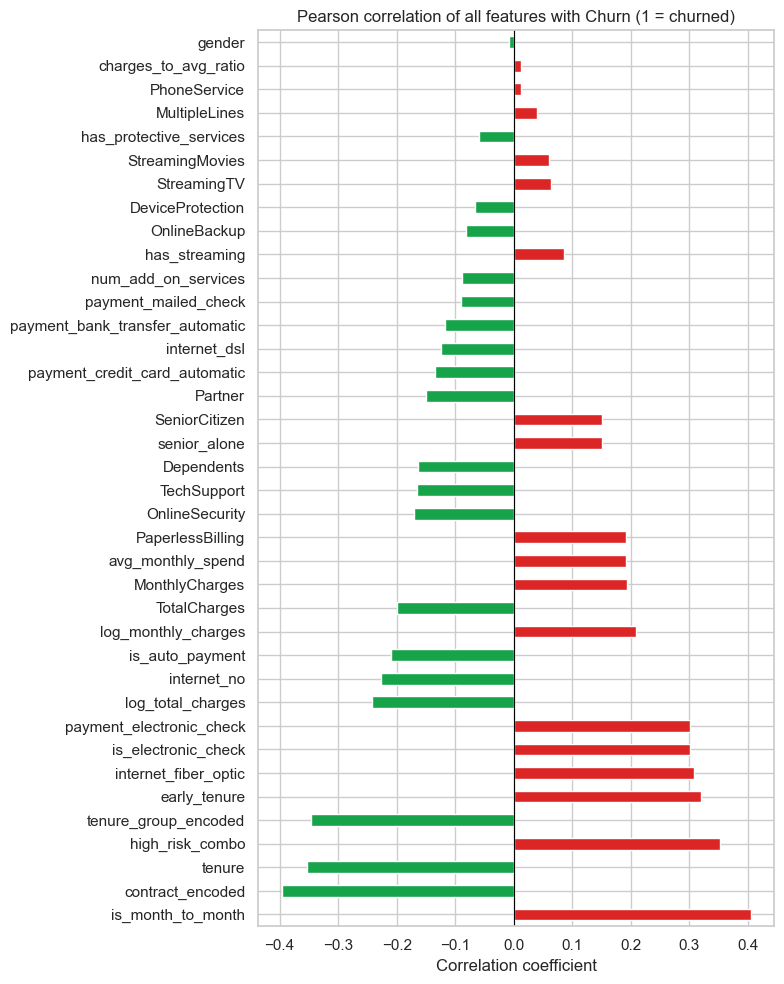


Top 10 positive correlators (churn risk factors):
is_month_to_month           0.405
high_risk_combo             0.353
early_tenure                0.320
internet_fiber_optic        0.307
is_electronic_check         0.301
payment_electronic_check    0.301
log_monthly_charges         0.210
MonthlyCharges              0.193
avg_monthly_spend           0.192
PaperlessBilling            0.191

Top 10 negative correlators (churn protection factors):
contract_encoded       -0.396
tenure                 -0.354
tenure_group_encoded   -0.347
log_total_charges      -0.242
internet_no            -0.228
is_auto_payment        -0.210
TotalCharges           -0.199
OnlineSecurity         -0.171
TechSupport            -0.165
Dependents             -0.163


In [14]:
# All columns are numeric at this point
corr_with_churn = (
    feat.corr()["Churn"]
    .drop("Churn")
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 10))
colors = ["#dc2626" if v > 0 else "#16a34a" for v in corr_with_churn]
corr_with_churn.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Pearson correlation of all features with Churn (1 = churned)")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

print("\nTop 10 positive correlators (churn risk factors):")
print(corr_with_churn[corr_with_churn > 0].head(10).round(3).to_string())
print("\nTop 10 negative correlators (churn protection factors):")
print(corr_with_churn[corr_with_churn < 0].head(10).round(3).to_string())

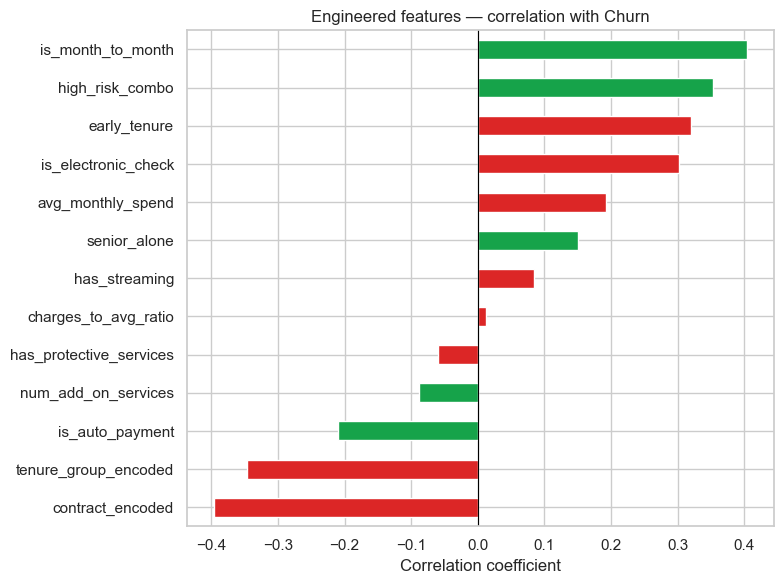

In [15]:
# Spot-check the engineered features we care most about
engineered_cols = [
    "avg_monthly_spend", "charges_to_avg_ratio",
    "num_add_on_services", "has_protective_services", "has_streaming",
    "is_month_to_month", "is_electronic_check", "is_auto_payment",
    "senior_alone", "early_tenure", "high_risk_combo",
    "tenure_group_encoded", "contract_encoded",
]

eng_corr = corr_with_churn.loc[[c for c in engineered_cols if c in corr_with_churn.index]]

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#dc2626" if v > 0 else "#16a34a" for v in eng_corr]
eng_corr.sort_values().plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Engineered features — correlation with Churn")
ax.set_xlabel("Correlation coefficient")
plt.tight_layout()
plt.show()

In [16]:
# Final dtype check to make sure everything must be numeric
non_numeric = feat.select_dtypes(include="object").columns.tolist()
if non_numeric:
    raise ValueError(f"Non-numeric columns still present: {non_numeric}")

null_counts = feat.isnull().sum()
if null_counts.any():
    print("WARNING — nulls found:")
    print(null_counts[null_counts > 0].to_string())

feat.to_csv(FEATURED_PATH, index=False)
print(f"Saved: {FEATURED_PATH}")
print(f"Shape: {feat.shape}  ({feat.shape[1] - 1} features and 1 target)")
print(f"Churn rate preserved: {feat['Churn'].mean():.1%}")
feat.head()

Saved: C:\Users\Ahana\Desktop\telco-churn-ml-lab\data\processed\telco_featured.csv
Shape: (7032, 39)  (38 features and 1 target)
Churn rate preserved: 26.6%


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,early_tenure,high_risk_combo,contract_encoded,internet_dsl,internet_fiber_optic,internet_no,payment_bank_transfer_automatic,payment_credit_card_automatic,payment_electronic_check,payment_mailed_check
0,0,0,1,0,1,0,0,0,1,0,...,1,1,0,True,False,False,False,False,True,False
1,1,0,0,0,34,1,0,1,0,1,...,0,0,1,True,False,False,False,False,False,True
2,1,0,0,0,2,1,0,1,1,0,...,1,1,0,True,False,False,False,False,False,True
3,1,0,0,0,45,0,0,1,0,1,...,0,0,1,True,False,False,True,False,False,False
4,0,0,0,0,2,1,0,0,0,0,...,1,1,0,False,True,False,False,False,True,False


### Summary

### Label Engineering
| Column | Before | After | Why |
|---|---|---|---|
| `Churn` | `"Yes"` / `"No"` | `1` / `0` | ML models require numeric targets |

### New Engineered Features
| Feature | Type | EDA Motivation |
|---|---|---|
| `avg_monthly_spend` | Numeric | Removes tenure confound from TotalCharges |
| `charges_to_avg_ratio` | Numeric | Detects price escalation since joining |
| `log_monthly_charges` | Numeric | Reduces right skew for linear models |
| `log_total_charges` | Numeric | Reduces right skew for linear models |
| `tenure_group_encoded` | Ordinal | Captures non-linear first-year cliff |
| `num_add_on_services` | Count | Service stickiness / lock-in |
| `has_protective_services` | Binary | 2x churn rate gap from EDA |
| `has_streaming` | Binary | Entertainment bundle engagement |
| `is_month_to_month` | Binary | Strongest predictor (42% vs 3% churn) |
| `is_electronic_check` | Binary | Manual pay = lower commitment signal |
| `is_auto_payment` | Binary | Auto-pay = friction to churn |
| `senior_alone` | Binary | Compound isolation + age risk |
| `early_tenure` | Binary | First-year cliff (0-12 months) |
| `high_risk_combo` | Binary | Month-to-month × early tenure interaction |
| `contract_encoded` | Ordinal | Commitment ladder (0/1/2) |
| `internet_*` (3 cols) | One-hot | InternetService - no natural order |
| `payment_*` (4 cols) | One-hot | PaymentMethod - no natural order |
